# Imports and definitions

In [1]:
# imports
from numpy import cos, sin, arctan, sqrt, exp
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from scipy.integrate import simpson
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.cm as cm
from tqdm import tqdm
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [3]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Head-on (Q vs P)

In [ ]:
sd = SimDir("../simulations/Headon_M=1,0.5-T=0.1,0.05-alpha=0,0.5pi-x0=8.001_h=3")
ts = sd.timeseries
gf = sd.gf

hor  = sd.horizons
hor1 = hor.get_apparent_horizon(1)
hor2 = hor.get_apparent_horizon(2)
muls = sd.multipoles

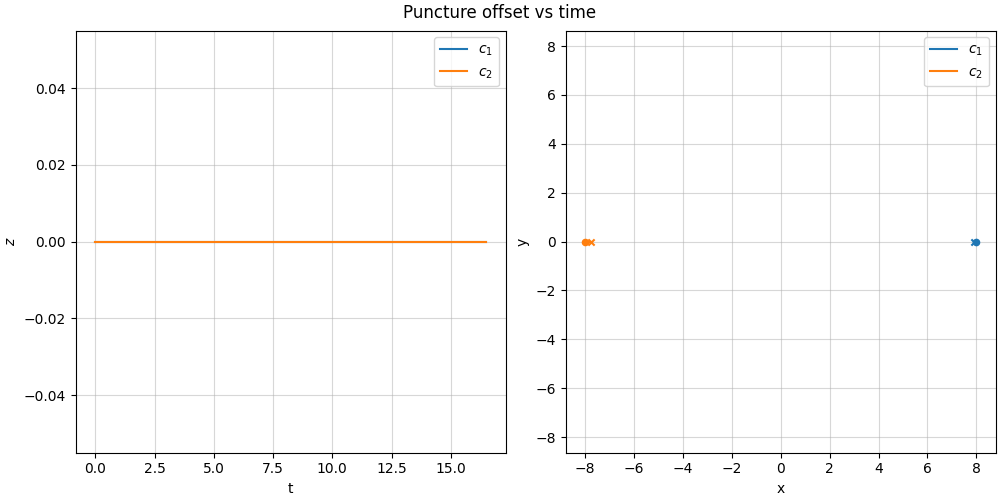

In [ ]:
c1_x = hor1.get_ah_property("centroid_x")
c1_y = hor1.get_ah_property("centroid_y")
c1_z = hor1.get_ah_property("centroid_z")

c2_x = hor2.get_ah_property("centroid_x")
c2_y = hor2.get_ah_property("centroid_y")
c2_z = hor2.get_ah_property("centroid_z")


fig, ax = plt.subplots(2, 2, figsize=(10,10), constrained_layout=True)
plt.suptitle("Puncture offset vs time")


ax[0,0].plot(c1_x.values, c1_y.values, color="C0", label=r"$c_1$")
ax[0,0].plot(c2_x.values, c2_y.values, color="C1", label=r"$c_2$")

ax[0,0].scatter([c1_x.values[0]],   [c1_y.values[0]],   color="C0", marker="o", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[0]],   [c2_y.values[0]],   color="C1", marker="o", s=20, zorder=10)
ax[0,0].scatter([c1_x.values[-1]],  [c1_y.values[-1]],  color="C0", marker="x", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[-1]],  [c2_y.values[-1]],  color="C1", marker="x", s=20, zorder=10)

ax[0,0].set_aspect('equal', adjustable='datalim')
ax[0,0].grid(alpha=0.5, zorder=-10)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].legend()


ax[0,1].plot(c1_x.t, c1_x.values, color="C0", label=r"$c_1$")
ax[0,1].plot(c2_x.t, c2_x.values, color="C1", label=r"$c_2$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel(r"$x$")
ax[0,1].legend();


ax[1,0].plot(c1_y.t, c1_y.values, color="C0", label=r"$c_1$")
ax[1,0].plot(c2_y.t, c2_y.values, color="C1", label=r"$c_2$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_ylabel(r"$y$")
ax[1,0].legend();


ax[1,1].plot(c1_z.t, c1_z.values, color="C0", label=r"$c_1$")
ax[1,1].plot(c2_z.t, c2_z.values, color="C1", label=r"$c_2$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_ylabel(r"$z$")
ax[1,1].legend();

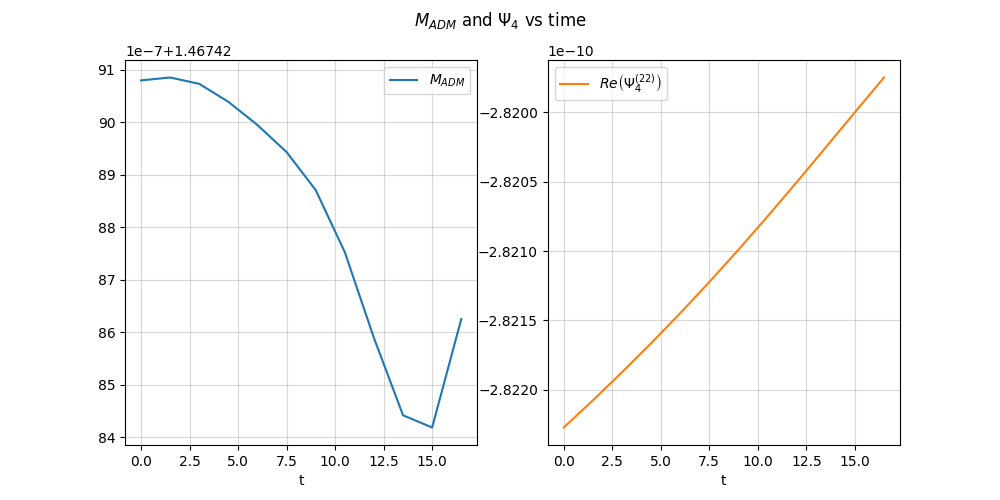

In [10]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$M_{ADM}$ and $\Psi_4$ vs time")

R = 240

M = hor[5,6].adm_energy
psi4_22 = muls["Psi4"][R][(2,2)]

ax1.plot(M.t, M.y, color="C0", label=r"$M_{ADM}$")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.legend()

ax2.plot(psi4_22.t, psi4_22.y.real, color="C1", label=r"$Re \left(\Psi_4^{(22)} \right)$")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.legend();

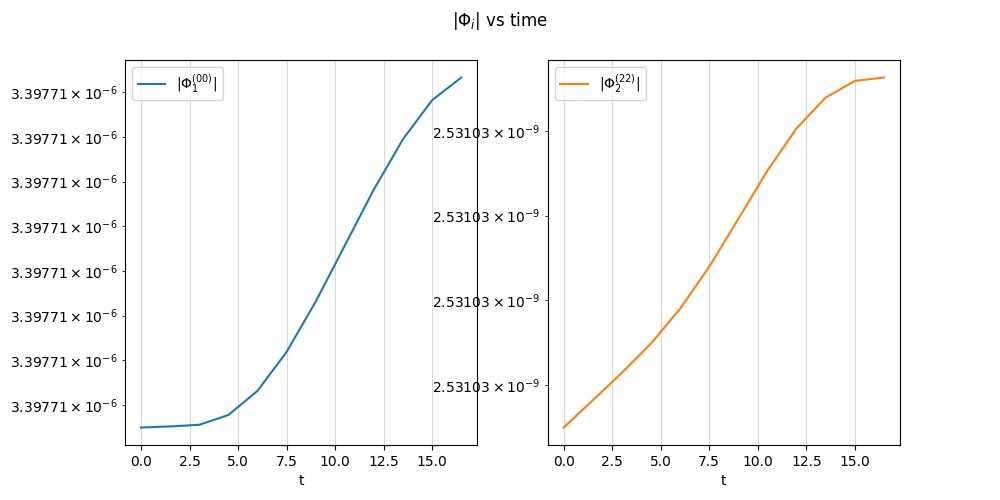

In [11]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$|\Phi_i|$ vs time")

R = 240

Phi1_00 = muls["Phi1"][R][(0,0)]
Phi2_22 = muls["Phi2"][R][(2,2)]

ax1.plot(Phi1_00.t, sqrt(Phi1_00.y.real**2 + Phi1_00.y.imag**2), label=r"$|\Phi_1^{(00)}|$", color="C0")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_yscale("log")
ax1.legend()

ax2.plot(Phi2_22.t, sqrt(Phi2_22.y.real**2 + Phi2_22.y.imag**2), label=r"$|\Phi_2^{(22)}|$", color="C1")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.set_yscale("log")
ax2.legend();

# Merger (Q vs P)

In [4]:
sd = SimDir("../simulations/Merger_M=0.5,0.5-T=0.05,0.05-alpha=0,0.5pi-x0=8.001_h=3")
ts = sd.timeseries
gf = sd.gf

hor  = sd.horizons
hor1 = hor.get_apparent_horizon(1)
hor2 = hor.get_apparent_horizon(2)
muls = sd.multipoles

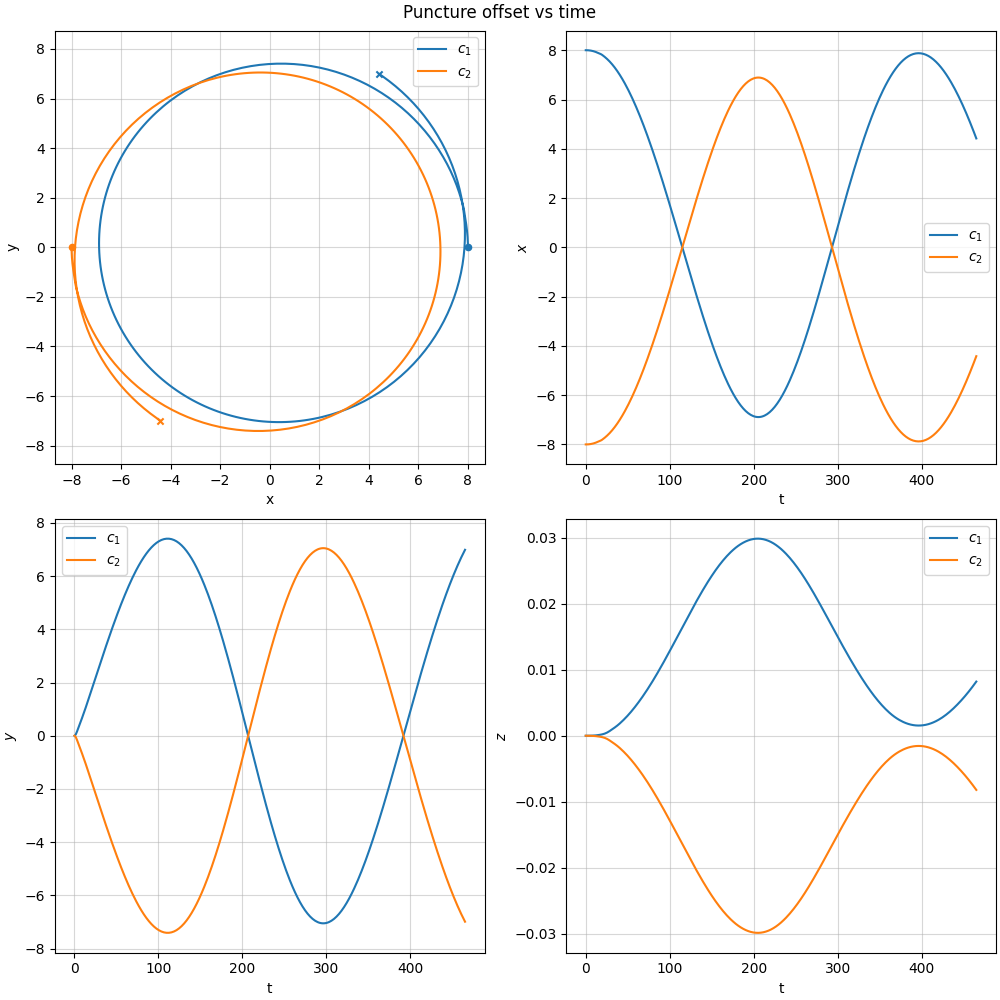

In [10]:
c1_x = hor1.get_ah_property("centroid_x")
c1_y = hor1.get_ah_property("centroid_y")
c1_z = hor1.get_ah_property("centroid_z")

c2_x = hor2.get_ah_property("centroid_x")
c2_y = hor2.get_ah_property("centroid_y")
c2_z = hor2.get_ah_property("centroid_z")


fig, ax = plt.subplots(2, 2, figsize=(10,10), constrained_layout=True)
plt.suptitle("Puncture offset vs time")


ax[0,0].plot(c1_x.values, c1_y.values, color="C0", label=r"$c_1$")
ax[0,0].plot(c2_x.values, c2_y.values, color="C1", label=r"$c_2$")

ax[0,0].scatter([c1_x.values[0]],   [c1_y.values[0]],   color="C0", marker="o", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[0]],   [c2_y.values[0]],   color="C1", marker="o", s=20, zorder=10)
ax[0,0].scatter([c1_x.values[-1]],  [c1_y.values[-1]],  color="C0", marker="x", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[-1]],  [c2_y.values[-1]],  color="C1", marker="x", s=20, zorder=10)

ax[0,0].set_aspect('equal', adjustable='datalim')
ax[0,0].grid(alpha=0.5, zorder=-10)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].legend()


ax[0,1].plot(c1_x.t, c1_x.values, color="C0", label=r"$c_1$")
ax[0,1].plot(c2_x.t, c2_x.values, color="C1", label=r"$c_2$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel(r"$x$")
ax[0,1].legend();


ax[1,0].plot(c1_y.t, c1_y.values, color="C0", label=r"$c_1$")
ax[1,0].plot(c2_y.t, c2_y.values, color="C1", label=r"$c_2$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_ylabel(r"$y$")
ax[1,0].legend();


ax[1,1].plot(c1_z.t, c1_z.values, color="C0", label=r"$c_1$")
ax[1,1].plot(c2_z.t, c2_z.values, color="C1", label=r"$c_2$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_ylabel(r"$z$")
ax[1,1].legend();

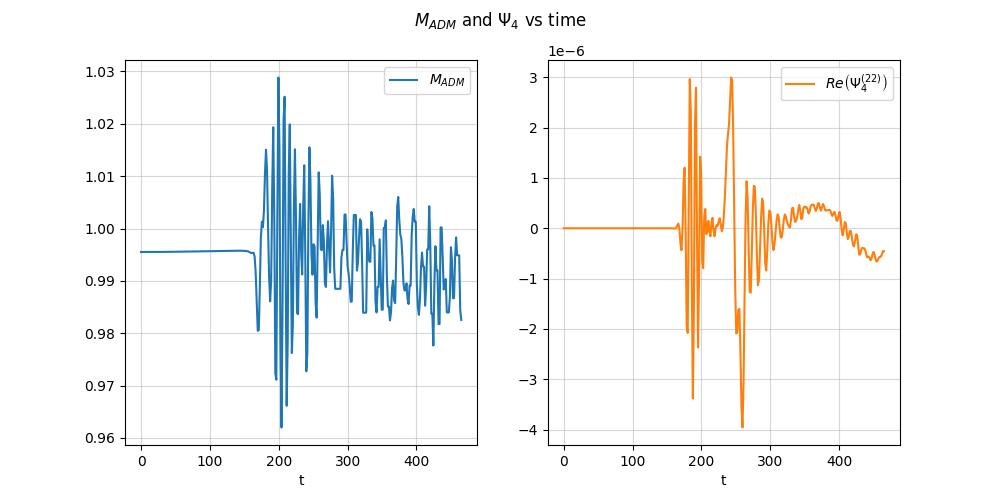

In [6]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$M_{ADM}$ and $\Psi_4$ vs time")

R = 240

M = hor[5,6].adm_energy
psi4_22 = muls["Psi4"][R][(2,2)]

ax1.plot(M.t, M.y, color="C0", label=r"$M_{ADM}$")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.legend()

ax2.plot(psi4_22.t, psi4_22.y.real, color="C1", label=r"$Re \left(\Psi_4^{(22)} \right)$")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.legend();

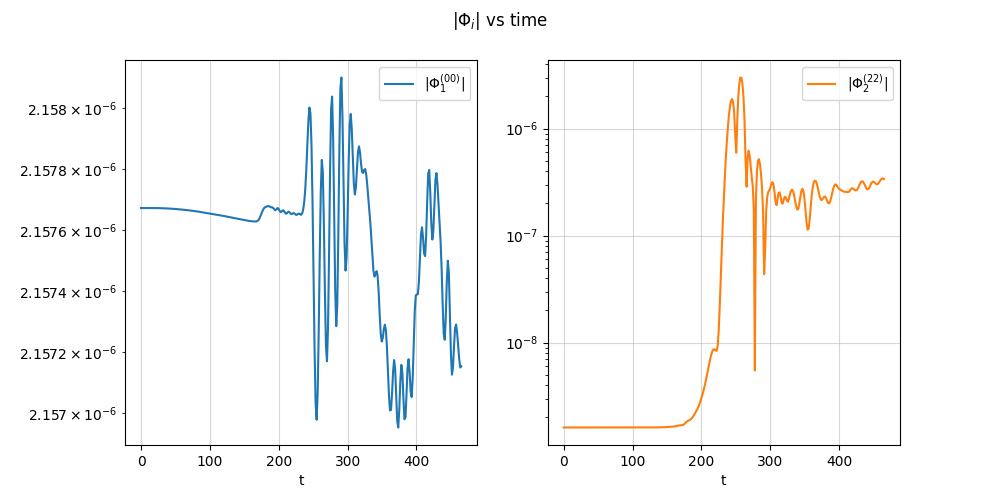

In [7]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$|\Phi_i|$ vs time")

R = 240

Phi1_00 = muls["Phi1"][R][(0,0)]
Phi2_22 = muls["Phi2"][R][(2,2)]

ax1.plot(Phi1_00.t, sqrt(Phi1_00.y.real**2 + Phi1_00.y.imag**2), label=r"$|\Phi_1^{(00)}|$", color="C0")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_yscale("log")
ax1.legend()

ax2.plot(Phi2_22.t, sqrt(Phi2_22.y.real**2 + Phi2_22.y.imag**2), label=r"$|\Phi_2^{(22)}|$", color="C1")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.set_yscale("log")
ax2.legend();